In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
import ModuloACP as macp
%matplotlib inline

In [17]:
# Cargar datos — separador ',', decimal '.', student_id como índice
datos = pd.read_csv('../datasets/ultimate_student_productivity_dataset_5000.csv', sep=',', decimal='.', index_col=0)
print('Dimensiones:', datos.shape)
datos.head()

Dimensiones: (5000, 20)


,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
student_id,,,,,,,,,,,,,,,,,,,,
1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [18]:
# Tipos de datos por columna
print(datos.dtypes)

age                       int64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality         object
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object


In [19]:
# Codificar columnas categóricas con label encoding (orden alfabético → entero)
categoricas = ['gender', 'academic_level', 'internet_quality']

for col in categoricas:
    categorias = sorted(datos[col].dropna().unique())
    mapeo = {cat: i for i, cat in enumerate(categorias)}
    datos[col] = datos[col].map(mapeo)
    print(f"'{col}' → {mapeo}")

'gender' → {'Female': 0, 'Male': 1, 'Other': 2}
'academic_level' → {'High School': 0, 'Postgraduate': 1, 'Undergraduate': 2}
'internet_quality' → {'Average': 0, 'Good': 1, 'Poor': 2}


In [20]:
# Eliminar nulos y verificar que todas las columnas son numéricas
datos = datos.dropna()
print('Dimensiones tras limpieza:', datos.shape)
print(datos.dtypes)

Dimensiones tras limpieza: (5000, 20)
age                       int64
gender                    int64
academic_level            int64
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality          int64
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object


In [21]:
# Crear el modelo ACP con 5 componentes principales
acp = macp.ACP(datos, n_componentes=5)

In [22]:
# Varianza explicada por cada componente principal
var = acp.var_explicada
print('Varianza explicada por componente (%)')
acumulada = 0
for i, v in enumerate(var):
    acumulada += v
    print(f'  Componente {i}: {round(v, 2)}%  (acumulada: {round(acumulada, 2)}%)')

Varianza explicada por componente (%)
  Componente 0: 18.06%  (acumulada: 18.06%)
  Componente 1: 9.31%  (acumulada: 27.37%)
  Componente 2: 5.68%  (acumulada: 33.05%)
  Componente 3: 5.34%  (acumulada: 38.39%)
  Componente 4: 5.27%  (acumulada: 43.66%)


In [23]:
# Correlación de las variables originales con cada componente principal
print('Correlación de variables con los componentes:')
acp.correlacion_var

Correlación de variables con los componentes:


component,0,1,2,3,4
variable,,,,,
age,-0.016412,-0.038726,0.107538,0.124208,-0.429787
gender,-0.021231,0.013022,0.014027,-0.145041,-0.043571
academic_level,0.004665,-0.036217,0.089223,0.103962,-0.523386
study_hours,0.562756,0.208361,0.499804,0.102594,-0.036669
self_study_hours,0.130493,0.125340,-0.328724,0.302638,-0.276129
online_classes_hours,0.010908,-0.029924,0.046811,0.290213,0.017273
social_media_hours,-0.164399,-0.152427,0.485990,-0.325113,0.186993
gaming_hours,-0.090891,-0.057429,0.436682,0.085271,0.005048
sleep_hours,0.262971,-0.438981,-0.396948,-0.169343,0.041259


In [24]:
# Coordenadas de las observaciones en el plano principal
print('Coordenadas de los estudiantes (primeras 10):')
acp.coordenadas_ind.head(10)

Coordenadas de los estudiantes (primeras 10):


component,0,1,2,3,4
student_id,,,,,
1,4.161852,0.152901,1.246808,-1.764007,0.802517
2,-2.470405,-1.563135,-0.273728,0.636266,0.803416
3,0.412514,-0.617243,-0.350367,-0.779495,0.878857
4,-2.222826,2.504604,0.149063,-0.232100,0.883995
5,2.318096,-0.003840,-0.192575,-2.324527,-0.132777
6,0.145652,-0.805816,-0.541301,-0.021457,-1.765010
7,-0.635530,1.833910,-0.381698,-1.811154,0.373070
8,0.744794,-0.000569,0.383559,0.552410,0.257731
9,2.057516,0.314588,0.475664,-2.129657,0.680559


In [25]:
# Contribución de cada observación a los componentes
print('Contribución de los estudiantes (primeras 10):')
acp.contribucion_ind.head(10)

Contribución de los estudiantes (primeras 10):


component,0,1,2,3,4
student_id,,,,,
1,0.000959,2.287942e-06,0.000273,5.828729e-04,0.000122
2,0.000338,2.666708e-04,0.000014,7.534250e-05,0.000123
3,0.000009,3.909932e-05,0.000021,1.129546e-04,0.000147
4,0.000273,6.445395e-04,0.000003,1.074469e-05,0.000148
5,0.000298,1.234522e-08,0.000007,1.011245e-03,0.000003
6,0.000001,6.017291e-05,0.000048,3.411649e-08,0.000592
7,0.000022,3.641433e-04,0.000025,6.131158e-04,0.000026
8,0.000031,1.787900e-07,0.000024,5.600764e-05,0.000013
9,0.000235,8.490347e-06,0.000038,8.513994e-04,0.000088


In [26]:
# Calidad de representación (cos²) de cada observación
print('Calidad de representación cos² (primeras 10):')
acp.cos2_ind.head(10)

Calidad de representación cos² (primeras 10):


component,0,1,2,3,4
student_id,,,,,
1,0.603363,8.143760e-04,0.054151,0.108394,0.022434
2,0.335039,1.341383e-01,0.004113,0.022225,0.035436
3,0.010492,2.349019e-02,0.007569,0.037463,0.047622
4,0.195923,2.487439e-01,0.000881,0.002136,0.030987
5,0.274268,7.526001e-07,0.001893,0.275792,0.000900
6,0.001445,4.421510e-02,0.019952,0.000031,0.212125
7,0.026467,2.203900e-01,0.009547,0.214954,0.009120
8,0.027550,1.608112e-08,0.007306,0.015155,0.003299
9,0.189975,4.441138e-03,0.010153,0.203530,0.020785


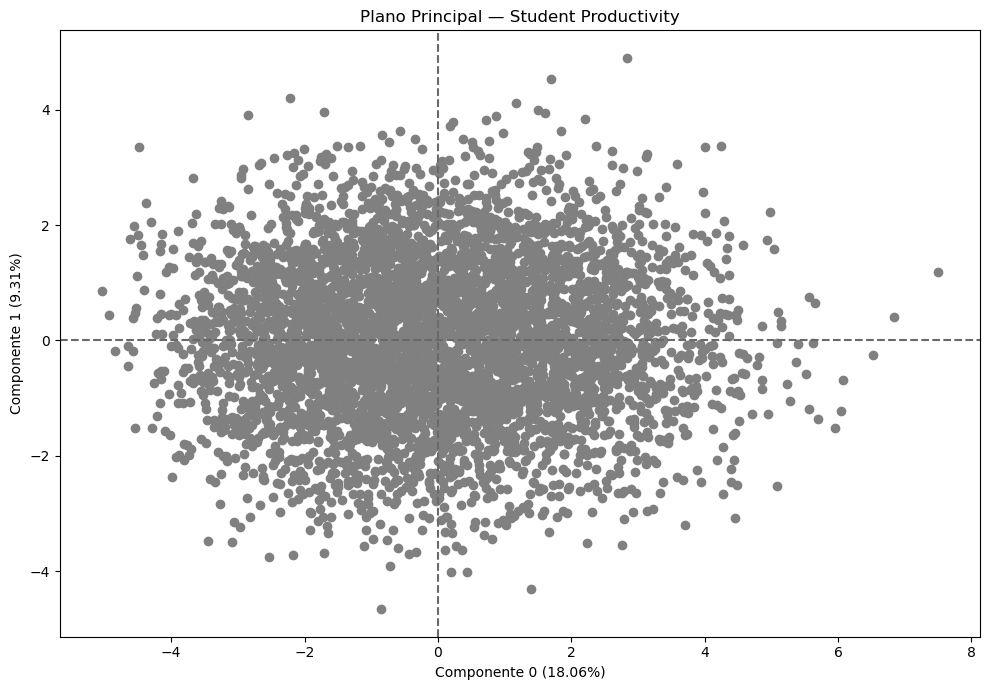

In [27]:
# Plano principal: posición de los estudiantes sobre los dos primeros componentes
# ind_labels=False por el volumen de datos (5000 estudiantes)
plt.figure(figsize=(10, 7))
acp.plot_plano_principal(ejes=[0, 1], ind_labels=False, titulo='Plano Principal — Student Productivity')
plt.tight_layout()
plt.show()

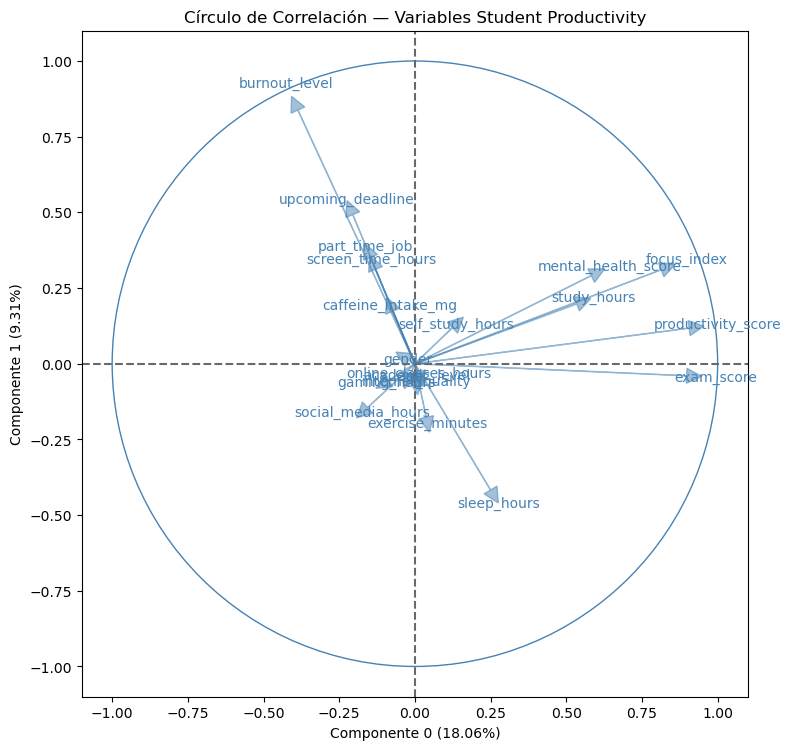

In [28]:
# Círculo de correlación: relación de las variables con los componentes
plt.figure(figsize=(8, 8))
acp.plot_circulo(ejes=[0, 1], var_labels=True, titulo='Círculo de Correlación — Variables Student Productivity')
plt.tight_layout()
plt.show()

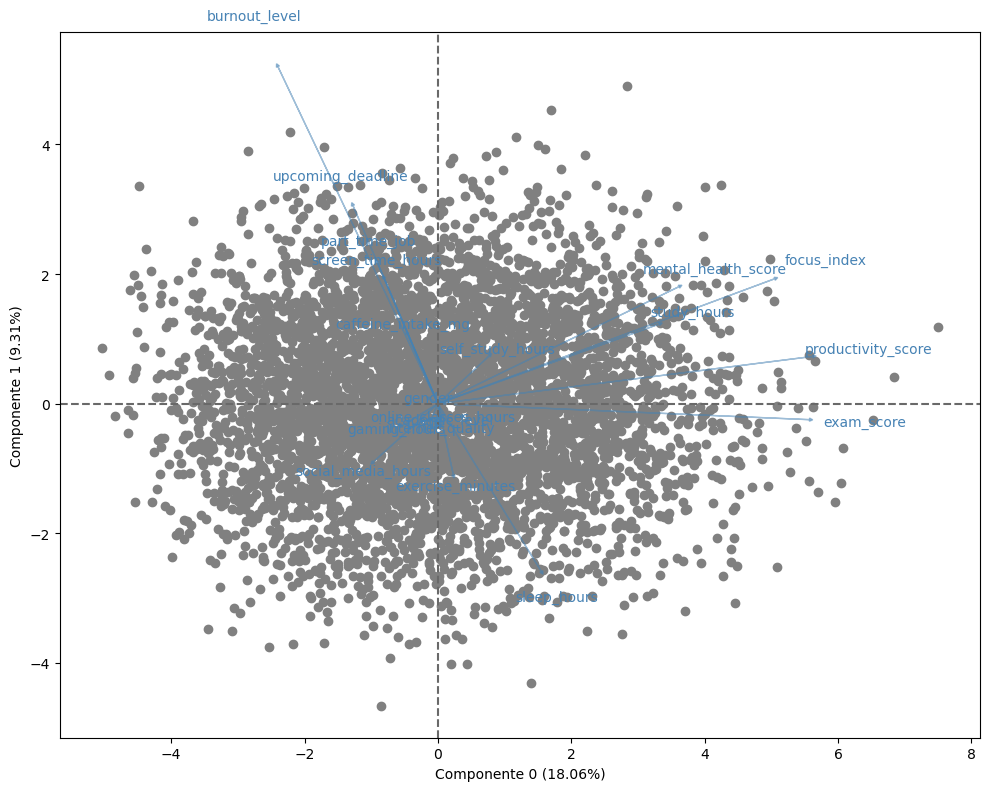

In [29]:
# Sobreposición: estudiantes y variables en el mismo plano
plt.figure(figsize=(10, 8))
acp.plot_sobreposicion(ejes=[0, 1], ind_labels=False, var_labels=True,
                       titulo='Sobreposición Plano-Círculo — Student Productivity')
plt.tight_layout()
plt.show()

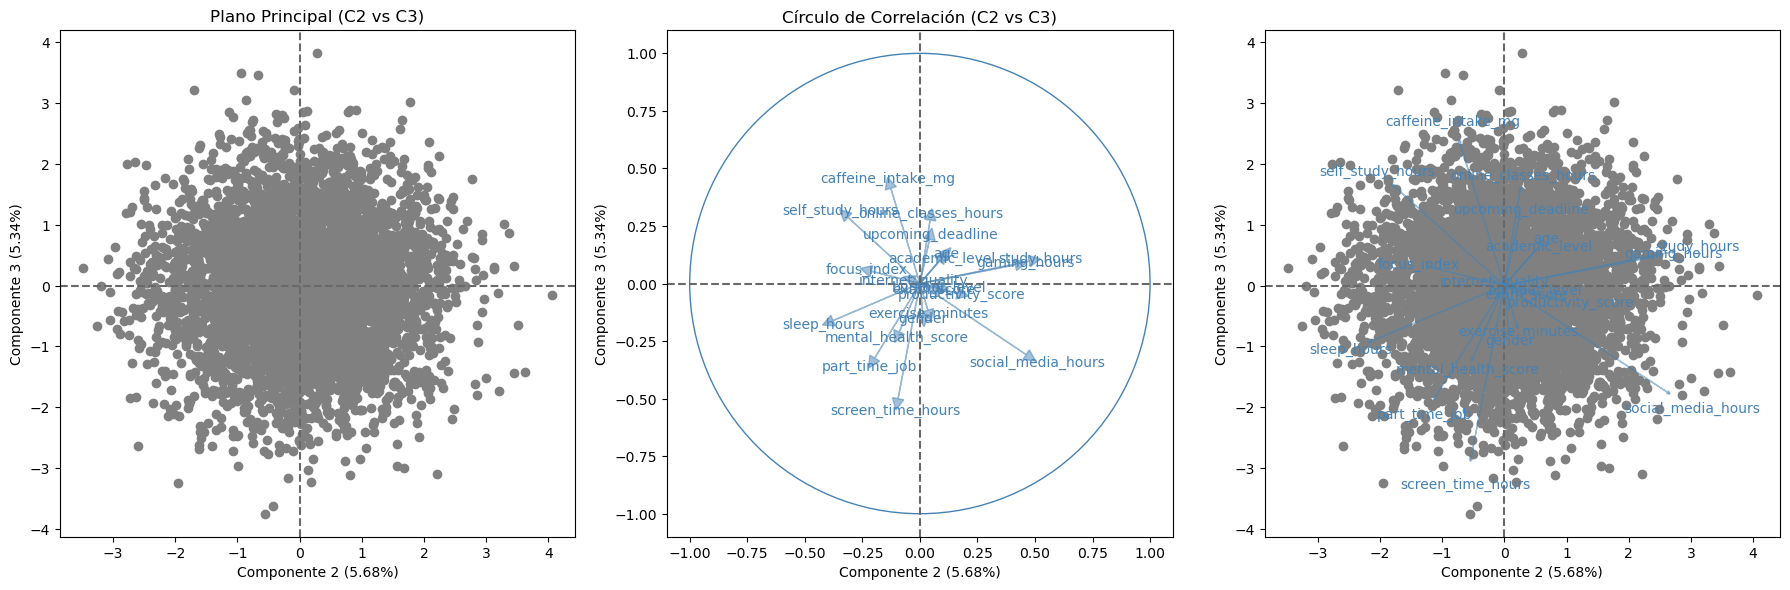

In [30]:
# Segunda perspectiva — componentes 2 y 3
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plt.sca(axes[0])
acp.plot_plano_principal(ejes=[2, 3], ind_labels=False, titulo='Plano Principal (C2 vs C3)')

plt.sca(axes[1])
acp.plot_circulo(ejes=[2, 3], var_labels=True, titulo='Círculo de Correlación (C2 vs C3)')

plt.sca(axes[2])
acp.plot_sobreposicion(ejes=[2, 3], ind_labels=False, var_labels=True, titulo='Sobreposición (C2 vs C3)')

plt.tight_layout()
plt.show()